## Freeze & New Head

In [2]:
pip install --upgrade torch torchvision torchaudio

   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   --- ------------------------------------ 9.4/114.5 MB 49.1 MB/s eta 0:00:03
   ----- ---------------------------------- 16.8/114.5 MB 40.7 MB/s eta 0:00:03
   -------- ------------------------------- 25.4/114.5 MB 41.3 MB/s eta 0:00:03
   ---------- ----------------------------- 29.6/114.5 MB 36.2 MB/s eta 0:00:03
   ----------- ---------------------------- 34.1/114.5 MB 33.3 MB/s eta 0:00:03
   ------------- -------------------------- 39.3/114.5 MB 32.1 MB/s eta 0:00:03
   --------------- ------------------------ 45.6/114.5 MB 31.2 MB/s eta 0:00:03
   ----------------- ---------------------- 50.3/114.5 MB 30.2 MB/s eta 0:00:03
   ------------------- -------------------- 56.1/114.5 MB 29.8 MB/s eta 0:00:02
   --------------------- ------------------ 62.1/114.5 MB 29.6 MB/s eta 0:00:02
   ------------------------ --------------- 70.5/114.5 MB 30.6 MB/s eta 0:00:02
   -------------------------- ------------- 75.0/1

  You can safely remove it manually.


In [1]:
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms
from typing import List
from PIL import Image

import torch
import os 
from datetime import datetime
import numpy as np 
# from PIL import ImageChops

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

AttributeError: module 'torch.fx.experimental.sym_node' has no attribute 'DynamicInt'

In [2]:
def clean_pred_truth(outputs, labels):
    out = [np.argmax((nn.functional.softmax(output, dim=-1).detach().numpy())) for output in outputs]
    true = labels.detach().numpy()
    return out, true


def get_cnf_mtr(labelss, outputss):
    predictions = []
    truths = []

    for outputs, labels in zip(outputss, labelss): 
        out, true = clean_pred_truth(outputs, labels)
        predictions.extend(out)
        truths.extend(true)

    cm = confusion_matrix(truths, predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # disp.plot(cmap=plt.cm.Blues)
    # plt.title("test")
    # plt.show()
    return disp

In [3]:
class ImageClassifier(nn.Module):
    def __init__(self, num_classes: int, backbone_name: str="resnet18", pretrained: bool=True):
        super().__init__()
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(
                weights="IMAGENET1K_V1" if pretrained else None
            )
            self.feature_dim = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else: 
            raise NotImplementedError("Add your preferred backbone")
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits


In [4]:
def add_new_classes(
        model: ImageClassifier, 
        new_class_names: List[str],
        freeze_backbone: bool = True, 
        freeze_old_classifier: bool = True
):
    old_num_classes = model.classifier.out_features
    new_num_classes = old_num_classes + len(new_class_names)

    new_classifier = nn.Linear(model.classifier.in_features, new_num_classes)

    with torch.no_grad():
        new_classifier.weight[:old_num_classes] = model.classifier.weight
        new_classifier.bias[:old_num_classes] = model.classifier.bias

    model.classifier = new_classifier

    if freeze_backbone: 
        for param in model.backbone.parameters():
                param.requires_grad = False

    if freeze_old_classifier: 
        model.classifier.weight[:old_num_classes].requires_grad = False
        model.classifier.bias[:old_num_classes].requires_grad = False

In [5]:
np.inf

inf

In [6]:
from tqdm.notebook import tqdm
import os 
def train_new_class(
        model: ImageClassifier, 
        train_loader: DataLoader,
        val_loader: DataLoader,
        epochs: int=10, 
        lr: float = 0.0001,
        device: str = "cuda" if torch.cuda.is_available() else "cpu", 
        model_save_path: str = "D:\RickCosta\Classifiers\it1",
):
    model.to(device)
    model.train()
    optimizer = optim.Adam(
      filter(lambda p: p.requires_grad, model.parameters()),
      lr=lr
    )

    criterion = nn.CrossEntropyLoss()

    print("Trainable parameter: \n")
    for name, param in model.named_parameters():
        if param.requires_grad: 
            print(f" {name}")
    last_low_loss = np.inf


    save_path = os.path.join(model_save_path, str(datetime.now()).replace(" ", "-").replace(":", "-"))
    os.makedirs(save_path)
    best_model_path = os.path.join(save_path, "best_classifier.pt")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        preds_t = []
        labels_t = []

        for images, labels in tqdm(train_loader, colour="Green"): 
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            preds_t.append(logits)
            labels_t.append(labels)

            running_loss += loss.item()
        print(
            f"Epoch {epoch+1} --- Training Loss {running_loss/len(train_loader):.4f}"
        )

        model.eval()

        preds_v = []
        labels_v = []

        with torch.no_grad():
            running_vloss = 0.0
            for images, labels in tqdm(val_loader, colour="Silver"):
                images, labels = images.to(device), labels.to(device)
                voutputs = model(images)
                vloss = criterion(voutputs, labels)
                running_vloss += vloss

                preds_v.append(voutputs)
                labels_v.append(labels)
                
        avg_vloss = running_loss/len(val_loader)
        print(
            f"----Val Loss {avg_vloss:.4f}"
        )        

        cnf_tr  = get_cnf_mtr(labelss=labels_t, outputss=preds_t)
        cnf_vl  = get_cnf_mtr(labelss=labels_v, outputss=preds_v)

        fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
        cnf_tr.plot(ax=ax1, cmap=plt.cm.Blues)
        ax1.set_title("Train")
        cnf_vl.plot(ax=ax2, cmap=plt.cm.Blues)
        ax2.set_title("Test")
        plt.show()


        if avg_vloss<last_low_loss: 
            # print(os.path.join(save_path, "best_classifier.pt"))
            torch.save(model.state_dict(), best_model_path)
            print(f"Model saved at: {epoch} - V Loss {avg_vloss:.4f}")
            last_low_loss = avg_vloss
    print(f"Final low loss is : {last_low_loss}")

    final_model_path = os.path.join(save_path, "last_classifier.pt")

    torch.save(model.state_dict(), final_model_path)


In [76]:


class MyCustomDataset(Dataset):
    def __init__(self, data_root, eliminate, transform=None):
        super().__init__()
        self.data_root = data_root
        self.transform = transform
        self.eliminate = eliminate
        
        self.samples = []
        self._load_samples()

    def _load_samples(self):
        classes = sorted(os.listdir(self.data_root))
        classes_filt = []
        for cls in classes:
            if cls not in self.eliminate: 
                classes_filt.append(cls)
        # classes = list(set(classes)-set(self.eliminate))
        classes = classes_filt.copy()
        self.class_to_idx = {cls:i for i, cls in enumerate(classes)}
        for class_name in classes: 
            class_dir = os.path.join(self.data_root, class_name)
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')): 
                    path = os.path.join(class_dir, file_name)
                    label = self.class_to_idx[class_name]
                    self.samples.append((path, label))
        self.target = [val[1] for val in self.samples]
        print(f"Loaded {len(self.samples)} samples.")

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")
        if self.transform: 
            image = self.transform(image)

        return image, label
    


def stratify_sampling(targets, test_size=0.2):

    train_inds, test_inds, _, _ = train_test_split(
        np.arange(len(targets)),
        targets, 
        test_size=test_size,
        stratify=targets
    )

    return train_inds, test_inds


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# transform = transforms.Compose([
#     transforms.Resize((225, 225)), 
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])



train_transform = transforms.Compose([
    
   
    transforms.Resize((256, 256)),
    
    
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    
    
    transforms.RandomHorizontalFlip(p=0.5),
    
    
    transforms.RandomRotation(15),
    
    
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)   # move 5% left/right/up/down
    ),
   
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    
    # Convert to tensor
    transforms.ToTensor(),
    
    # Normalize (important for ResNet)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
dataset = MyCustomDataset(  
    data_root="D:\RickCosta\SampleData\Cropped_data", 
    transform=transform,
    eliminate=["78-97   # 89", "98-107   # 57"]
)


Loaded 124 samples.


In [10]:
train_inds, test_inds = stratify_sampling(dataset.target)

In [11]:
train_ds = Subset(dataset, train_inds)
val_ds = Subset(dataset, test_inds)

train_loader = DataLoader(train_ds, batch_size=5, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=5, shuffle=False)

In [29]:
old_model = ImageClassifier(num_classes=4)

Trainable parameter: 

 backbone.conv1.weight
 backbone.bn1.weight
 backbone.bn1.bias
 backbone.layer1.0.conv1.weight
 backbone.layer1.0.bn1.weight
 backbone.layer1.0.bn1.bias
 backbone.layer1.0.conv2.weight
 backbone.layer1.0.bn2.weight
 backbone.layer1.0.bn2.bias
 backbone.layer1.1.conv1.weight
 backbone.layer1.1.bn1.weight
 backbone.layer1.1.bn1.bias
 backbone.layer1.1.conv2.weight
 backbone.layer1.1.bn2.weight
 backbone.layer1.1.bn2.bias
 backbone.layer2.0.conv1.weight
 backbone.layer2.0.bn1.weight
 backbone.layer2.0.bn1.bias
 backbone.layer2.0.conv2.weight
 backbone.layer2.0.bn2.weight
 backbone.layer2.0.bn2.bias
 backbone.layer2.0.downsample.0.weight
 backbone.layer2.0.downsample.1.weight
 backbone.layer2.0.downsample.1.bias
 backbone.layer2.1.conv1.weight
 backbone.layer2.1.bn1.weight
 backbone.layer2.1.bn1.bias
 backbone.layer2.1.conv2.weight
 backbone.layer2.1.bn2.weight
 backbone.layer2.1.bn2.bias
 backbone.layer3.0.conv1.weight
 backbone.layer3.0.bn1.weight
 backbone.layer3.

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1 --- Training Loss 0.4963


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 1.9850


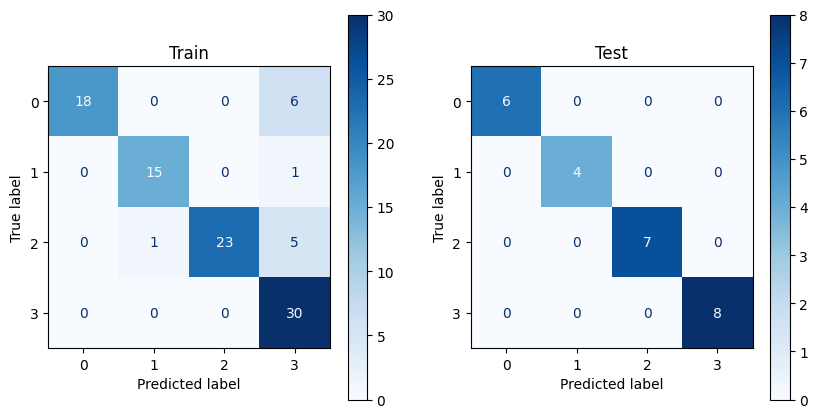

Model saved at: 0 - V Loss 1.9850


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2 --- Training Loss 0.1474


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.5894


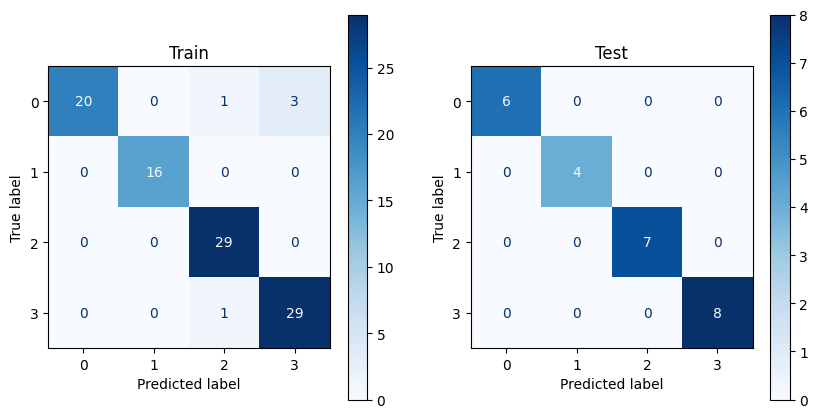

Model saved at: 1 - V Loss 0.5894


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 3 --- Training Loss 0.0657


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.2628


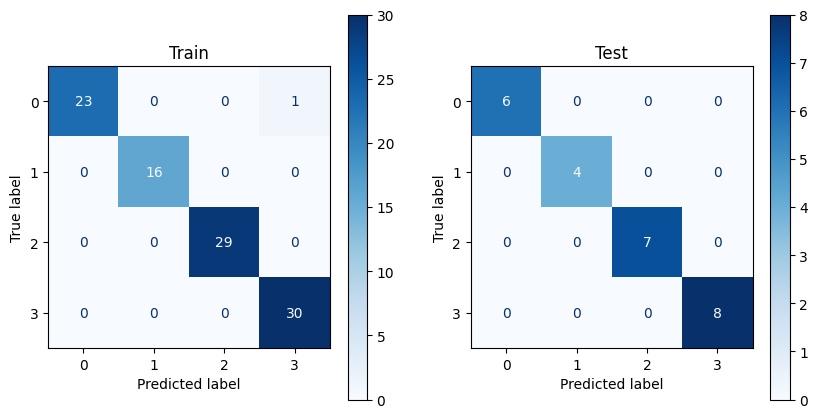

Model saved at: 2 - V Loss 0.2628


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 4 --- Training Loss 0.1545


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.6180


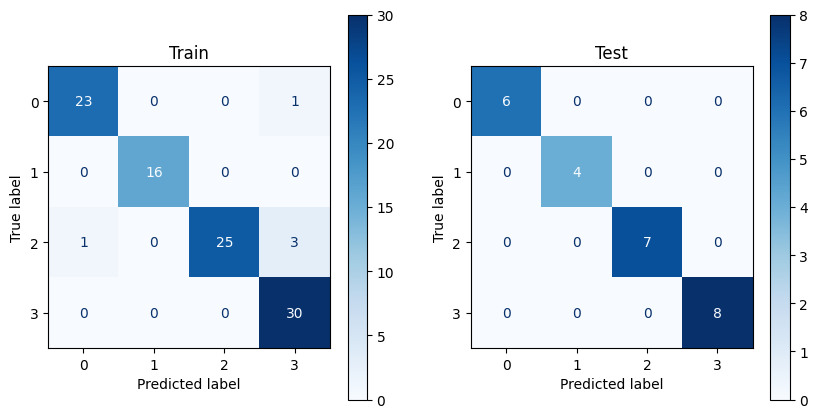

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 5 --- Training Loss 0.0307


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.1228


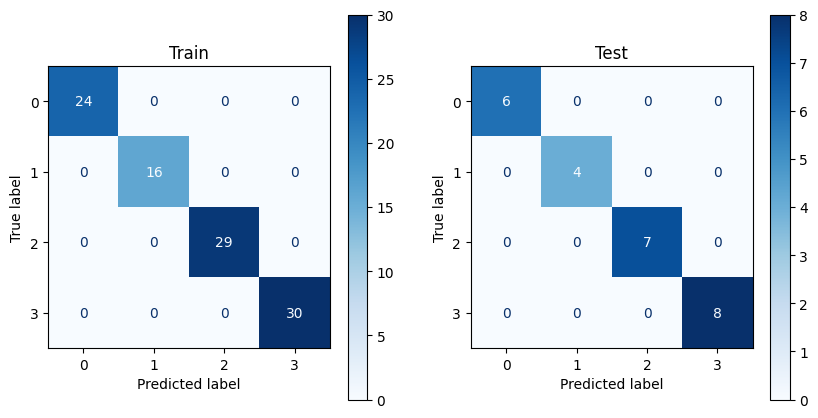

Model saved at: 4 - V Loss 0.1228


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 6 --- Training Loss 0.1126


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.4504


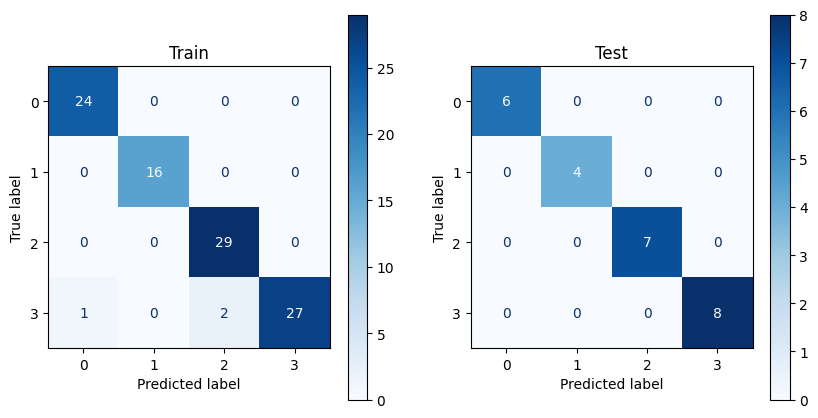

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 7 --- Training Loss 0.0797


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.3190


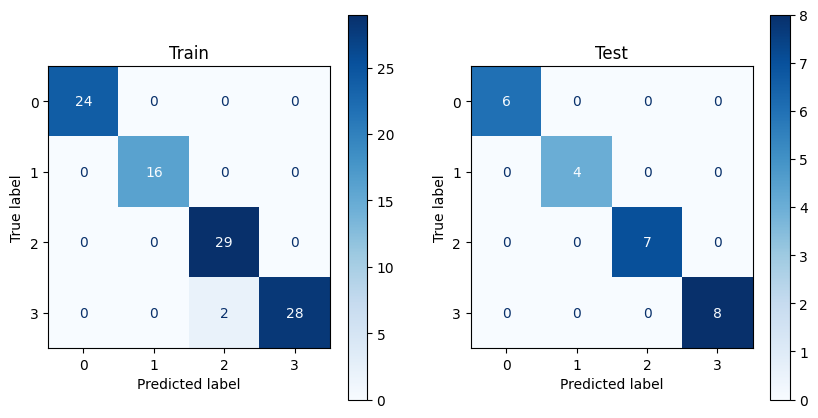

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 8 --- Training Loss 0.0377


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.1509


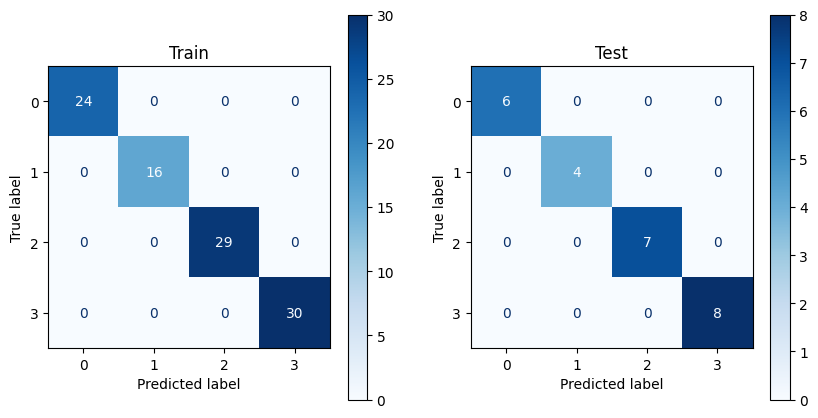

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 9 --- Training Loss 0.0195


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.0778


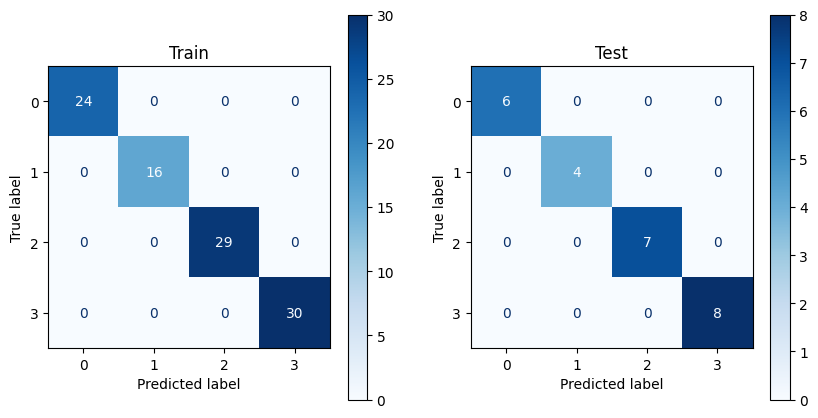

Model saved at: 8 - V Loss 0.0778


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 10 --- Training Loss 0.0297


  0%|          | 0/5 [00:00<?, ?it/s]

----Val Loss 0.1190


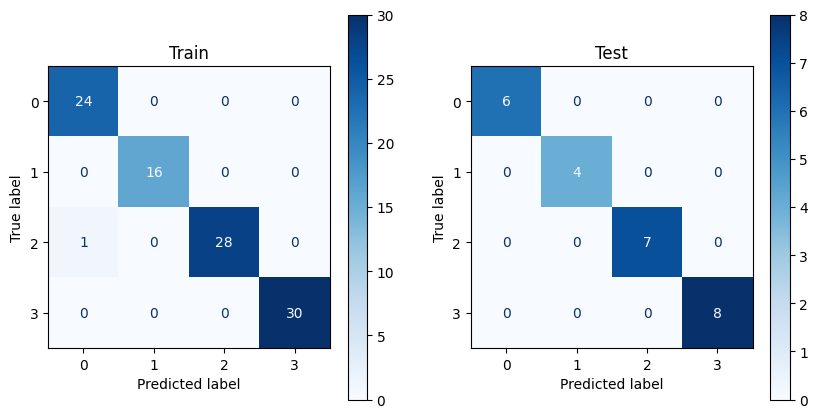

Final low loss is : 0.07780522571410983


In [30]:
train_new_class(old_model, train_loader=train_loader, val_loader=val_loader, epochs=10)

## Load pretrained


In [101]:
import torch

pretrained_model = ImageClassifier(num_classes=4)
pretrained_model.load_state_dict(torch.load(r"D:\RickCosta\Classifiers\it1\2026-03-19-13-17-27.005442\last_classifier.pt"))



<All keys matched successfully>

In [102]:
pretrained_model.eval()
preds = []
truths = []

for imgs, lbls in val_loader: 
    with torch.no_grad():
        prediction_pre = pretrained_model(imgs)
        # out, true = clean_pred_truth(prediction_pre, lbls)
        preds.append(prediction_pre)
        truths.append(lbls)


In [103]:
truths

[tensor([0, 1, 2, 3, 2]),
 tensor([2, 2, 0, 2, 3]),
 tensor([3, 3, 3, 1, 3]),
 tensor([2, 2, 1, 0, 0]),
 tensor([0, 3, 3, 1, 0])]

In [104]:
preds

[tensor([[ 8.5079, -1.8056, -3.4647, -2.4593],
         [-4.1251,  5.9954, -2.6227, -1.6288],
         [-3.2348, -2.4834,  6.2413, -2.4195],
         [-0.6817, -2.2941, -4.0945,  6.3430],
         [-2.8810, -2.2814,  5.8096, -2.7184]]),
 tensor([[-3.5362, -2.5756,  5.6204, -1.5114],
         [-3.8711, -2.0555,  6.2521, -3.5198],
         [10.0046, -2.1941, -6.7080, -1.3643],
         [-3.3918, -2.9018,  6.9328, -3.1142],
         [-1.7027, -2.2246, -5.6254,  7.6691]]),
 tensor([[ 0.0317, -3.0800, -4.4540,  6.8903],
         [-2.4855, -3.3040, -3.4065,  8.3028],
         [-1.9110, -3.1491, -4.9747,  7.8494],
         [-4.0600,  6.2304, -2.7673, -1.8046],
         [-1.6088, -1.6274, -4.4160,  5.9965]]),
 tensor([[-3.6884, -2.4094,  4.9453, -1.7156],
         [-3.4901, -2.2844,  6.2135, -2.8143],
         [-5.1465,  7.0576, -3.4490, -0.9012],
         [ 8.8064, -2.2062, -5.2261, -1.6804],
         [ 7.3650, -1.8429, -3.8687, -2.3135]]),
 tensor([[ 8.4038, -1.6445, -4.1224, -2.8761],
     

In [105]:
cnfmat = get_cnf_mtr(labelss=truths, outputss=preds)

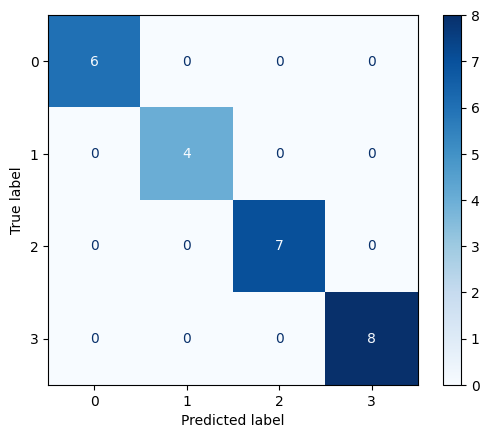

In [106]:
cnfmat.plot(cmap=plt.cm.Blues)

## Class Incremental

In [107]:
last_class_ind = pretrained_model.classifier.out_features-1

In [108]:

class IncrementalDataset(Dataset):
    def __init__(self, data_root, eliminate, last_class_ind, transform=None):
        super().__init__()
        self.data_root = data_root
        self.transform = transform
        self.eliminate = eliminate
        self.last_class_ind = last_class_ind
        
        self.samples = []
        self._load_samples()

    def get_indices(self, last_ind, len_new):
        return list(range(last_ind+1, len_new+last_ind+1))

    def _load_samples(self):
        classes = sorted(os.listdir(self.data_root))
        classes_filt = []

        for cls in classes:
            if cls not in self.eliminate: 
                classes_filt.append(cls)
        classes = classes_filt.copy()

        total_classes = len(classes) 
        indices = self.get_indices(self.last_class_ind, total_classes)
        print(f"Last Ind: {self.last_class_ind}, Total new classes: {total_classes}")
        self.class_to_idx = {cls:i for cls, i in zip(classes, indices)}
        print(f"Class to ind: {self.class_to_idx}")
        for class_name in classes: 
            class_dir = os.path.join(self.data_root, class_name)
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')): 
                    path = os.path.join(class_dir, file_name)
                    label = self.class_to_idx[class_name]
                    self.samples.append((path, label))
        self.target = [val[1] for val in self.samples]
        print(f"Loaded {len(self.samples)} samples.")

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index):
        path, label = self.samples[index]
        image = Image.open(path).convert("RGB")
        if self.transform: 
            image = self.transform(image)

        return image, label
    

In [109]:
dataset = MyCustomDataset(
    data_root="D:\RickCosta\SampleData\Cropped_data", 
    transform=transform,
    eliminate=["78-97   # 89", "98-107   # 57"]
)


Loaded 124 samples.


In [110]:
classes_eliminated = ["78-97   # 89", "98-107   # 57"]

data_root = r"D:\RickCosta\SampleData\Cropped_data"
folders = os.listdir(data_root)

filtered_incremental = []

for folder in folders: 
    if folder not in classes_eliminated: 
        filtered_incremental.append(folder)


In [111]:
filtered_incremental.append("98-107   # 57")

In [112]:
filtered_incremental

['05-19   # 67',
 '108-117   # 78',
 '20-37   # 57',
 '58-77   610',
 '98-107   # 57']

In [113]:
incre_dataset = IncrementalDataset(data_root=data_root, eliminate=filtered_incremental, last_class_ind=pretrained_model.classifier.out_features-1, transform=transform)

Last Ind: 3, Total new classes: 1
Class to ind: {'78-97   # 89': 4}
Loaded 40 samples.


In [114]:
def add_new_classes(
        model: ImageClassifier, 
        new_class_names: List[str], 
        freeze_backbone: bool = True, 
        freeze_old_classifier: bool = True
):
    old_num_classes = model.classifier.out_features
    new_num_classes = old_num_classes+len(new_class_names)

    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False
    
    if freeze_old_classifier:
        for param in model.classifier.parameters():
            param.requires_grad = False

    new_classifier = nn.Linear(model.classifier.in_features, new_num_classes)
    with torch.no_grad():
        new_classifier.weight[:old_num_classes] = model.classifier.weight
        new_classifier.bias[:old_num_classes] = model.classifier.bias

    model.classifier = new_classifier

In [115]:
add_new_classes(model=pretrained_model, new_class_names=['78-97   # 89'])

In [116]:
pretrained_model.classifier.out_features

5

In [117]:
trainind, testind = stratify_sampling(incre_dataset.target, test_size=0.2)

In [118]:
trainind

array([23, 33, 11, 15,  3, 21, 10, 26, 19, 34, 35, 14, 32, 27, 29, 24, 28,
        4, 31, 17,  0, 12, 13, 25, 37,  8,  7,  1, 39, 18,  6, 16])

In [119]:
testind

array([36, 20,  2, 38, 30, 22,  5,  9])

In [120]:
train_incre = Subset(incre_dataset, trainind)
test_incre = Subset(incre_dataset, testind)

In [121]:
train_loader_incre = DataLoader(train_incre, shuffle=True, batch_size=3)
test_loader_incre = DataLoader(test_incre, shuffle=False, batch_size=3)

Trainable parameter: 

 classifier.weight
 classifier.bias


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1 --- Training Loss 2.5643


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 9.4025


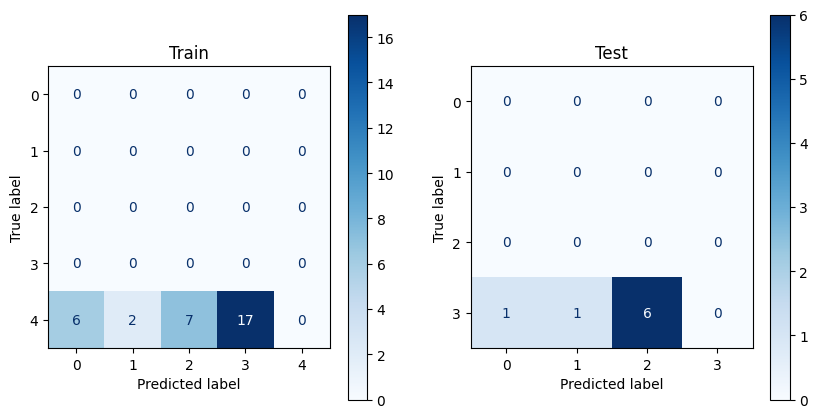

Model saved at: 0 - V Loss 9.4025


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2 --- Training Loss 1.6897


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 6.1955


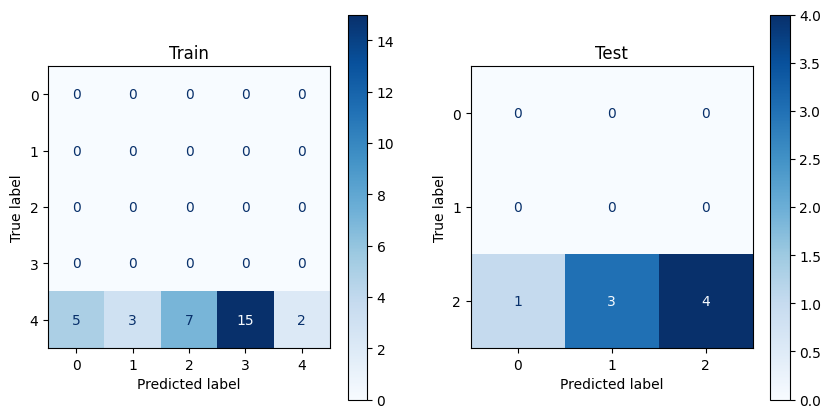

Model saved at: 1 - V Loss 6.1955


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3 --- Training Loss 0.9754


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 3.5765


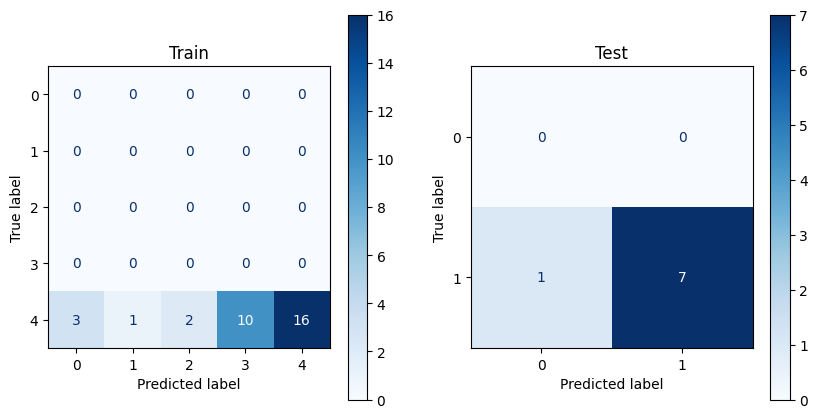

Model saved at: 2 - V Loss 3.5765


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 4 --- Training Loss 0.5784


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 2.1210


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


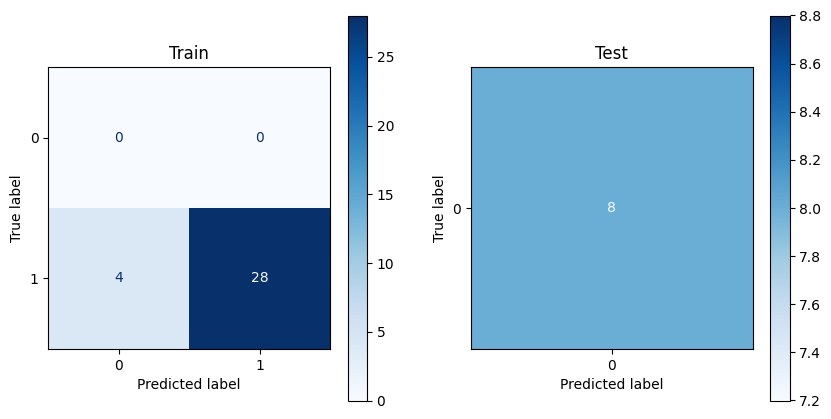

Model saved at: 3 - V Loss 2.1210


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 5 --- Training Loss 0.3214


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 1.1786


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


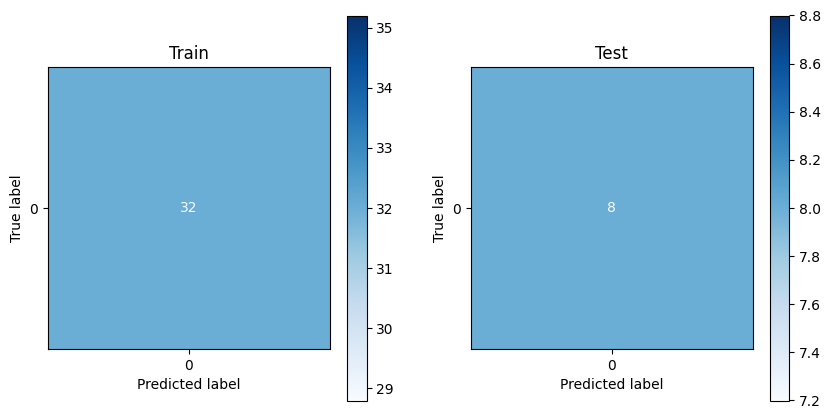

Model saved at: 4 - V Loss 1.1786


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 6 --- Training Loss 0.2020


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.7406


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


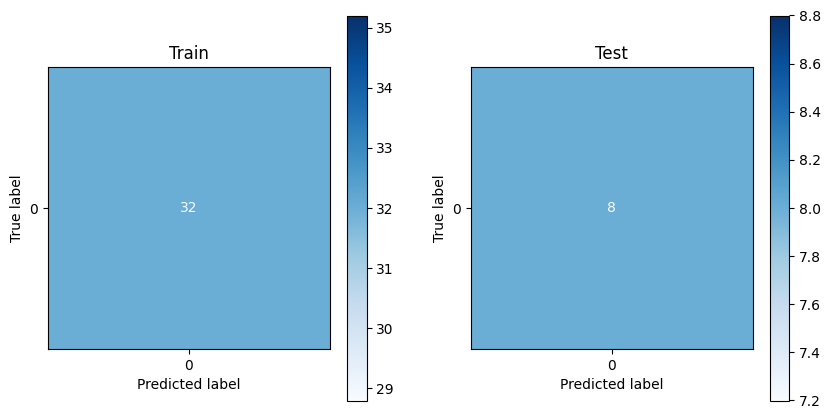

Model saved at: 5 - V Loss 0.7406


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 7 --- Training Loss 0.1525


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.5591


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


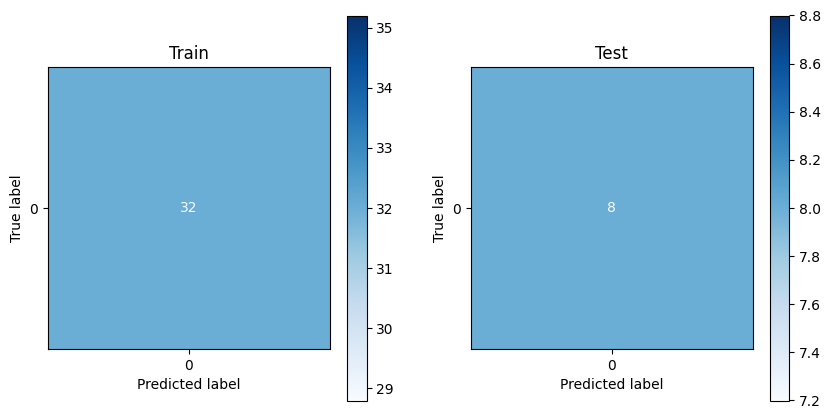

Model saved at: 6 - V Loss 0.5591


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 8 --- Training Loss 0.1085


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.3978


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


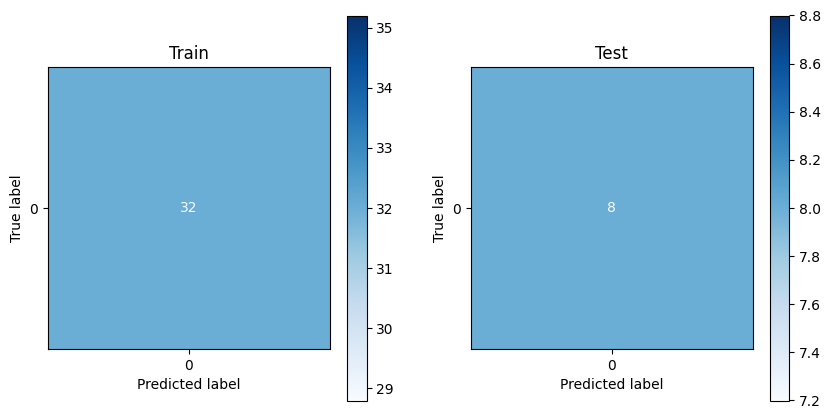

Model saved at: 7 - V Loss 0.3978


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 9 --- Training Loss 0.0797


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.2924


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


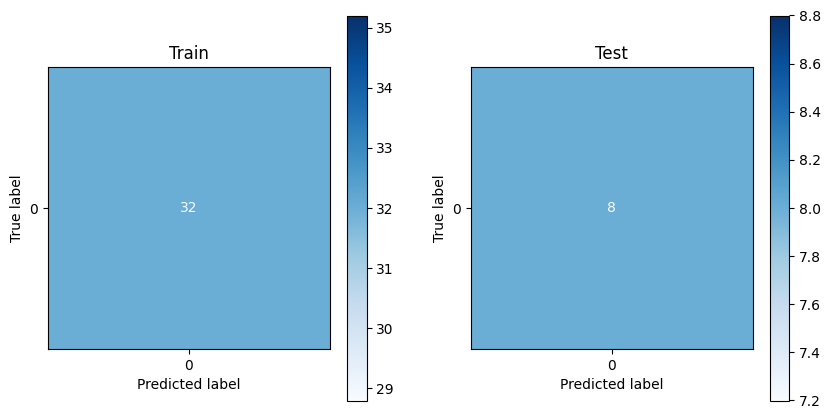

Model saved at: 8 - V Loss 0.2924


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10 --- Training Loss 0.0691


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.2535


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


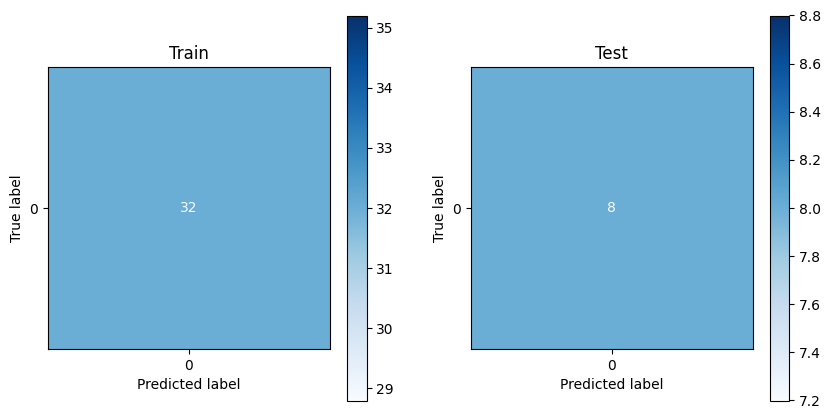

Model saved at: 9 - V Loss 0.2535


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 11 --- Training Loss 0.0610


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.2235


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


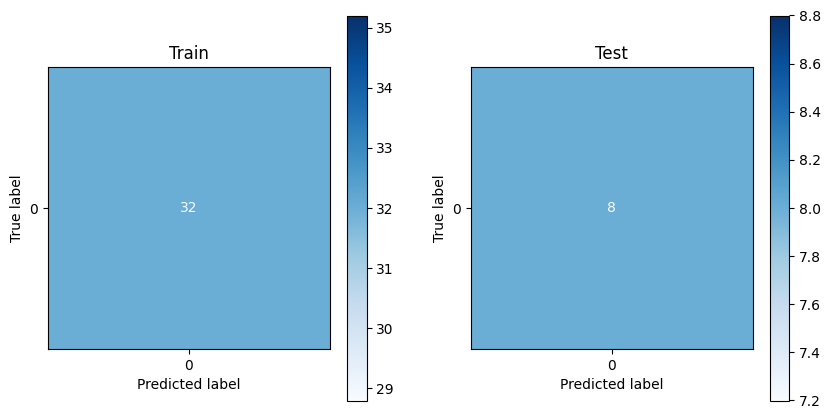

Model saved at: 10 - V Loss 0.2235


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 12 --- Training Loss 0.0522


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1913


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


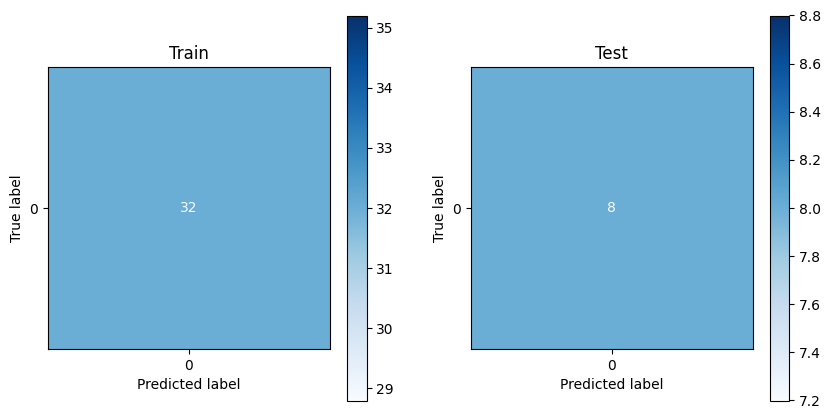

Model saved at: 11 - V Loss 0.1913


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 13 --- Training Loss 0.0491


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1802


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


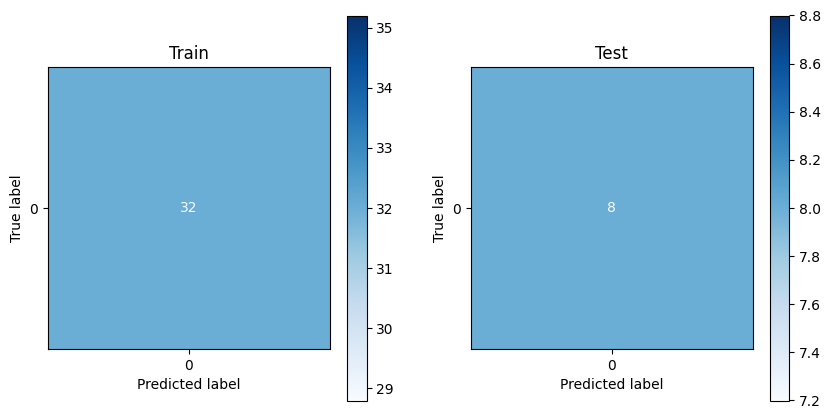

Model saved at: 12 - V Loss 0.1802


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 14 --- Training Loss 0.0394


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1446


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


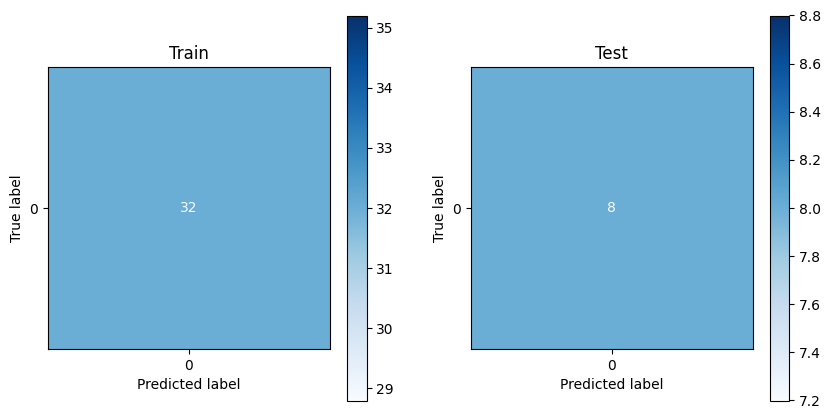

Model saved at: 13 - V Loss 0.1446


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 15 --- Training Loss 0.0353


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1295


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


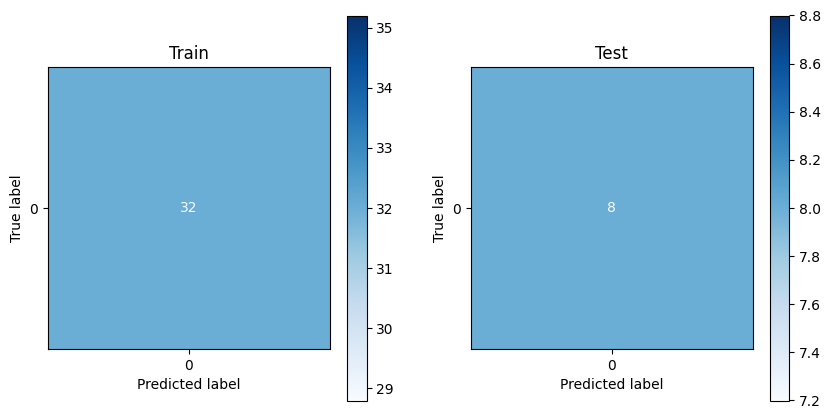

Model saved at: 14 - V Loss 0.1295


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 16 --- Training Loss 0.0332


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1217


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


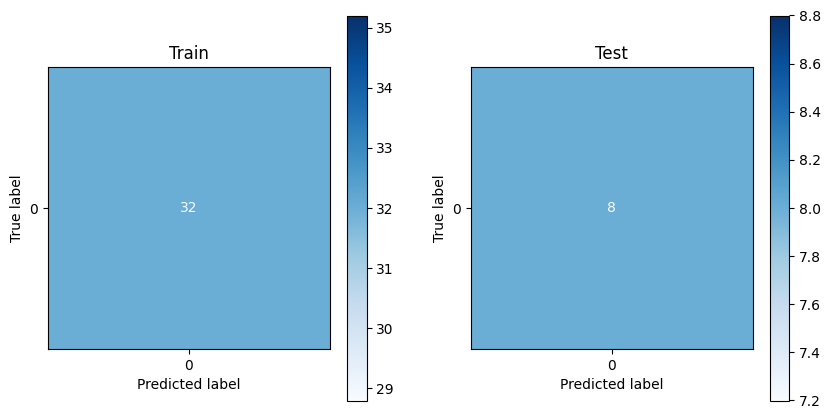

Model saved at: 15 - V Loss 0.1217


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 17 --- Training Loss 0.0303


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1110


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


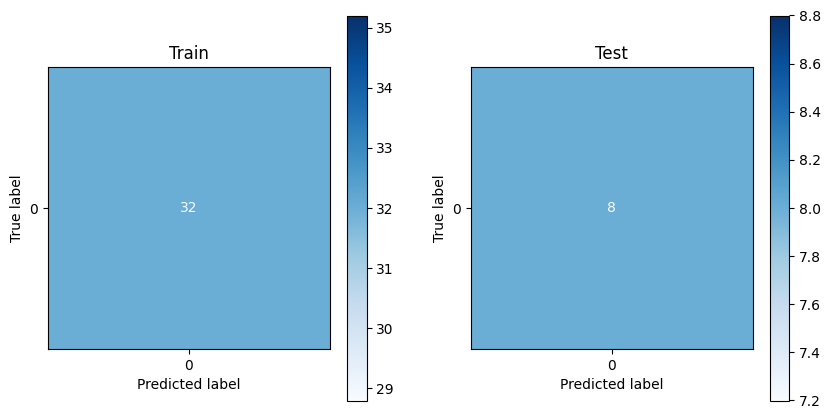

Model saved at: 16 - V Loss 0.1110


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 18 --- Training Loss 0.0308


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.1129


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


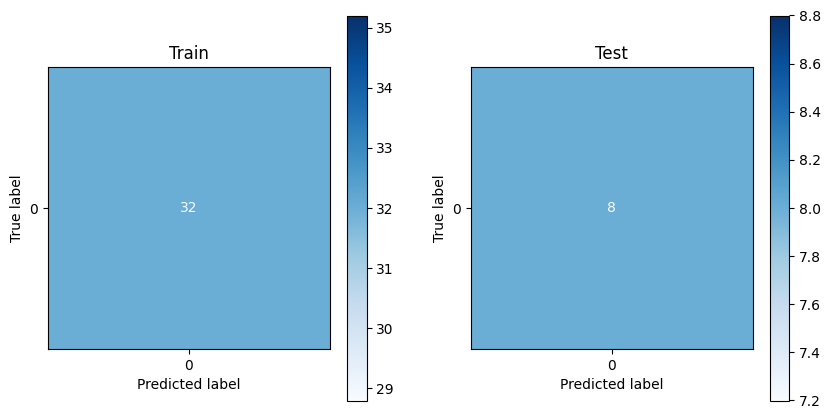

  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 19 --- Training Loss 0.0269


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.0986


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


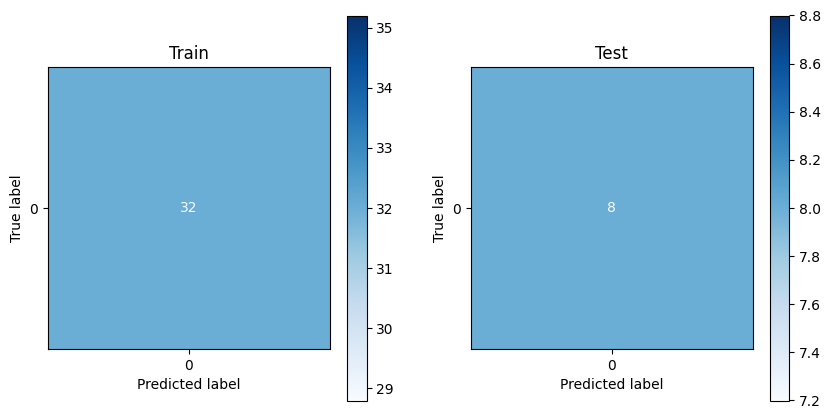

Model saved at: 18 - V Loss 0.0986


  0%|          | 0/11 [00:00<?, ?it/s]

Epoch 20 --- Training Loss 0.0241


  0%|          | 0/3 [00:00<?, ?it/s]

----Val Loss 0.0883


d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


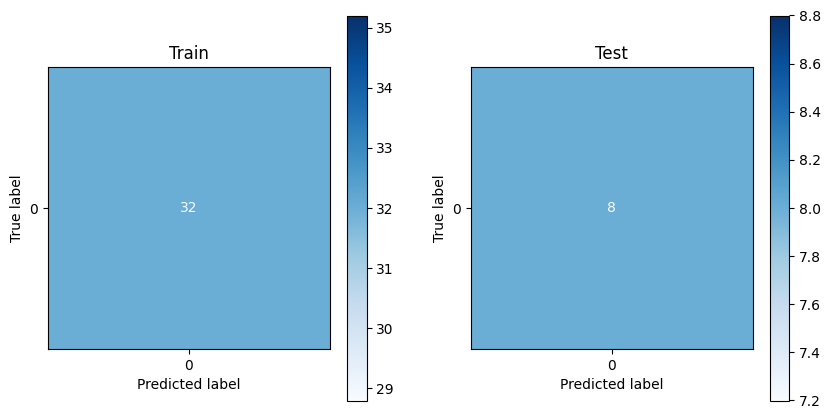

Model saved at: 19 - V Loss 0.0883
Final low loss is : 0.08826933863262336


In [122]:
train_new_class(pretrained_model, train_loader=train_loader_incre, val_loader=test_loader_incre, epochs=20)

In [125]:
labels = []
preds = []

pretrained_model.eval()

with torch.no_grad():
    for img_bt, lbl_bt in test_loader_incre: 
        out = pretrained_model(img_bt)
        labels.append(lbl_bt)
        preds.append(out)

In [126]:
mtr = get_cnf_mtr(labels, preds)

d:\RickCosta\.venv\lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


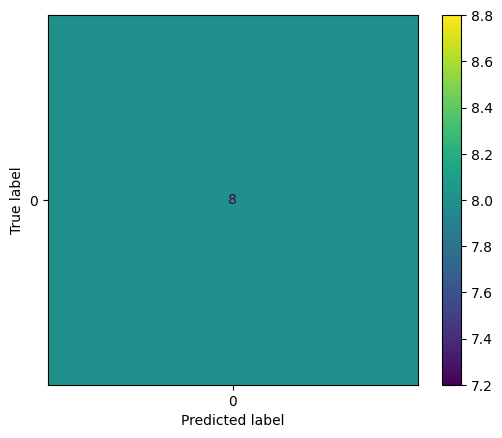

In [127]:
mtr.plot()

In [129]:
preds

[tensor([[-2.4733, -5.3601, -4.2485, -1.6774,  2.4791],
         [-4.6885, -4.4285, -2.9867, -3.2547,  1.8966],
         [-5.1952, -4.7302, -3.5051, -3.9576,  2.2159]]),
 tensor([[-2.3163, -4.3193, -3.5456, -2.7126,  1.7021],
         [-4.1225, -5.9321, -4.9138, -0.9227,  2.6805],
         [-3.4729, -4.8029, -3.9205, -3.4467,  2.2770]]),
 tensor([[-4.3009, -3.6778, -2.9154, -4.0755,  1.4993],
         [-3.8193, -3.7667, -3.5102, -5.3181,  1.7921]])]

In [128]:
pretrained_model.classifier.out_features

5

In [130]:
labels

[tensor([4, 4, 4]), tensor([4, 4, 4]), tensor([4, 4])]

In [131]:
whole_data = MyCustomDataset(data_root=r"D:\RickCosta\SampleData\Cropped_data", eliminate=["98-107   # 57"], transform=transform)

Loaded 164 samples.


In [132]:
whole_data.class_to_idx

{'05-19   # 67': 0,
 '108-117   # 78': 1,
 '20-37   # 57': 2,
 '58-77   610': 3,
 '78-97   # 89': 4}

In [133]:
whole_data_loader = DataLoader(whole_data, batch_size=10)

In [134]:
labels = []
preds = []

pretrained_model.eval()

with torch.no_grad():
    for img_bt, lbl_bt in whole_data_loader: 
        out = pretrained_model(img_bt)
        labels.append(lbl_bt)
        preds.append(out)

In [135]:
mtr = get_cnf_mtr(labels, preds)

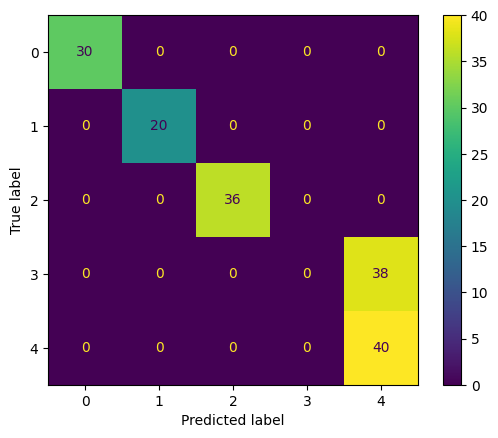

In [136]:
mtr.plot()

In [137]:
whole_data.class_to_idx

{'05-19   # 67': 0,
 '108-117   # 78': 1,
 '20-37   # 57': 2,
 '58-77   610': 3,
 '78-97   # 89': 4}